In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def golden_section_search(f, a: float, b: float, opt: bool, epsilon_x: float = 1e-4, epsilon_r: float = 1e-2, n: int = 10) -> float:
    """Golden Section Search useful for searching maxima or minima in one variable functions"""
    x0 = a - 1
    xf = b + 1
    dx = 1e-2
    xold = None
    # Method
    GR = (np.sqrt(5) - 1) / 2
    d = GR * (b - a)
    x1 = a + d
    x2 = b - d
    f1 = f(x1)
    f2 = f(x2)
    
    for i in range(n):
        if opt:
            optimization = "maximum"
            condition = f1 > f2
            print(f"Main idea: {a} < {x2} < {x1} < {b}")
        else:
            optimization = "minimum"
            condition = f1 < f2
        if condition:
            a = x2 # Discard interval [a, x2]
            x2 = x1 # Note that new_x2 = old_x1 (golden number made that)
            f2 = f1
            d = GR * (b - a)
                
            x1 = a + d # only recomputes the x1 in this case
            f1 = f(x1)
            x_opt = (x1 + x2) / 2
            print(f"Estimated {optimization} at ({x_opt}, {f(x_opt)})")
            if xold is not None:
                error = np.abs((x_opt - xold) / x_opt)
                if error <= epsilon_r or (b - a) <= epsilon_x:
                    print(f"Converges in iteration {i + 1}, maximum in: ({x_opt}, {f(x_opt)}) \n interval size: {b - a} and relative approximate error: {error}")
                    break
            xold = x_opt 
        else: 
            b = x1 # Discard [x1, b]
            x1 = x2
            f1 = f2
            d = GR * (b - a)
            
            x2 = b - d
            f2 = f(x2)
            x_opt = (x1 + x2) / 2
            print(f"Estimated {optimization} at ({x_opt}, {f(x_opt)})")
            if xold is not None:
                error = np.abs((x_opt - xold) / x_opt)
                if error <= epsilon_r or (b - a) <= epsilon_x:
                    print(f"Converges in iteration {i + 1}, maximum in: ({x_opt}, {f(x_opt)}) \n interval size: {b - a} and relative approximate error: {error}")
                    break
            xold = x_opt
    # Graphical Insight
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=150)
    x = np.arange(x0, xf + dx, dx)
    f_an = f(x)
    # Plots
    ax.plot(x, f_an, label=fr"Function")
    ax.plot(x_opt, f(x_opt), 'ro', label=f"Critical {optimization}")

    # Decoration
    ax.grid(visible=True, color="gray", linestyle=":", linewidth=0.7, alpha=0.5)
    ax.legend(fontsize=9)
    ax.set_xlim([x0, xf])
    ax.set_ylim([f(x_opt) - 5, f(x_opt) + 5])
    ax.set_title(f"Finding {optimization} using Golden Search Method")
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")


    maximum_values = (x_opt, f(x_opt)) # tuple
    return maximum_values

Main idea: -2 < 0.2917960675006306 < 1.7082039324993694 < 4
Estimated maximum at (2.1458980337503157, 5.7912589535722265)
Main idea: 0.2917960675006306 < 1.7082039324993694 < 2.583592135001262 < 4
Estimated maximum at (2.8541019662496847, 4.746163285366453)
Main idea: 1.7082039324993694 < 2.583592135001262 < 3.1246117974981074 < 4
Estimated maximum at (2.4164078649987384, 5.8584769601093125)
Main idea: 1.7082039324993694 < 2.2492235949962147 < 2.583592135001262 < 3.1246117974981074
Estimated maximum at (2.1458980337503157, 5.7912589535722265)
Main idea: 1.7082039324993694 < 2.0425724725044168 < 2.2492235949962147 < 2.583592135001262
Estimated maximum at (2.3130823037528394, 5.884786135103283)
Main idea: 2.0425724725044168 < 2.2492235949962147 < 2.376941012509464 < 2.583592135001262
Estimated maximum at (2.416407864998739, 5.8584769601093125)
Main idea: 2.2492235949962147 < 2.376941012509464 < 2.455874717488013 < 2.583592135001262
Estimated maximum at (2.352549156242114, 5.8831381619459

(np.float64(2.322399163798265), np.float64(5.885290656178611))

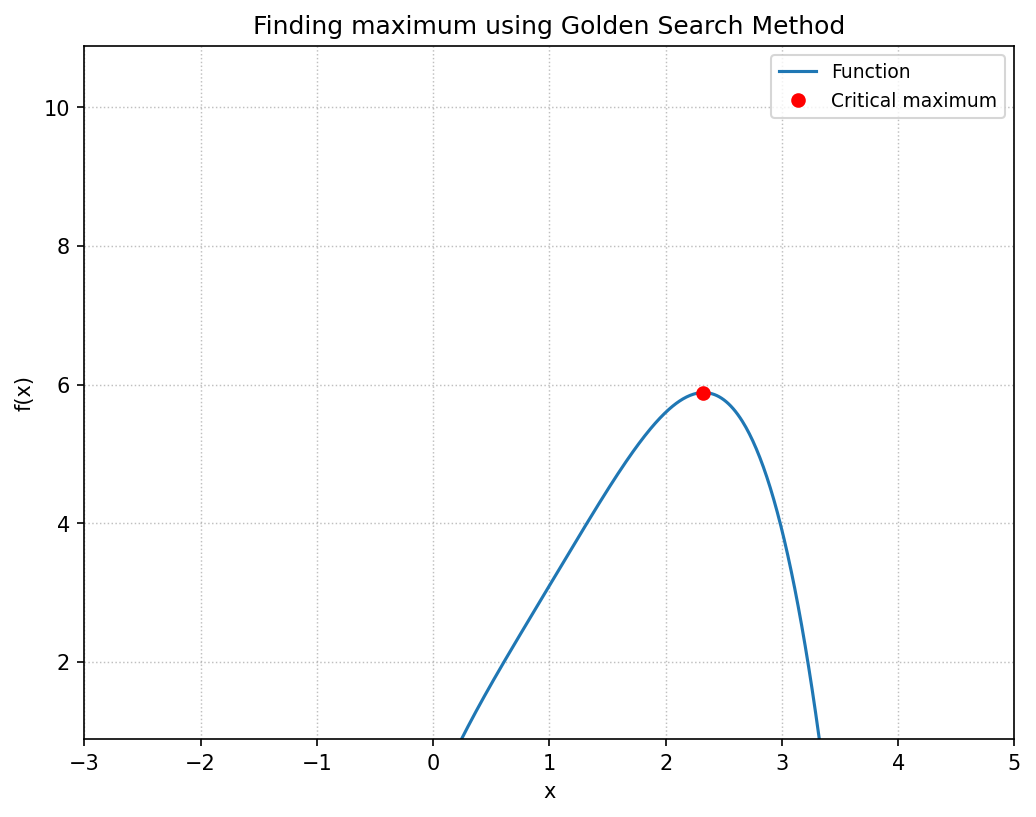

In [3]:
fx = lambda x: 4 * x - 1.8 * x**2 + 1.2 * x**3 - 0.3 * x**4
xl = -2; xu = 4; e = 1e-2
golden_section_search(fx, xl, xu, 1)

Estimated minimum at (2.76393202250021, 6.055728090000841)
Estimated minimum at (3.23606797749979, 6.055728090000841)
Estimated minimum at (2.944271909999159, 6.003105620015141)
Estimated minimum at (3.1246117974981074, 6.015528100075711)
Estimated minimum at (3.013155617496425, 6.000173070271712)
Estimated minimum at (2.944271909999159, 6.003105620015141)
Estimated minimum at (2.986844382503575, 6.000173070271712)
Estimated minimum at (3.013155617496425, 6.000173070271712)
Converges in iteration 8, maximum in: (3.013155617496425, 6.000173070271712) 
 interval size: 0.08514494500883263 and relative approximate error: 0.008732119522824823


(np.float64(3.013155617496425), np.float64(6.000173070271712))

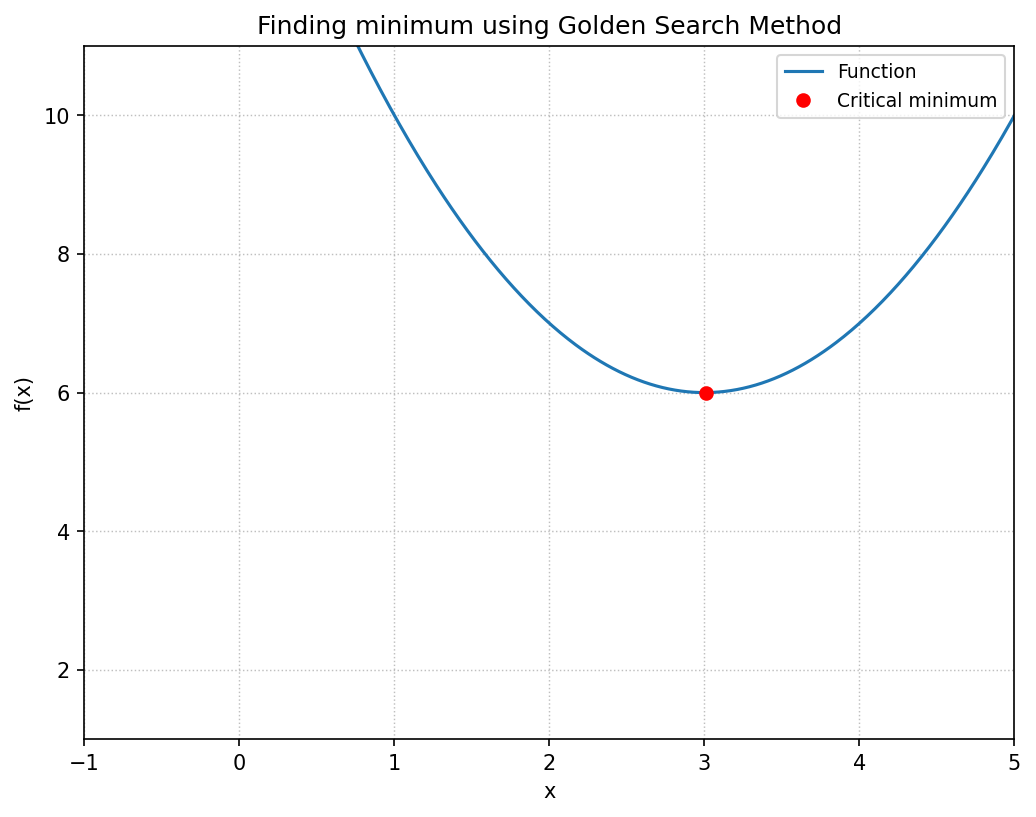

In [4]:
g = lambda x: x**2 - 6 * x + 15
xl = 0
xu = 4
golden_section_search(g, xl, xu, 0)

In [5]:
def parabolic_interpolation(fx, x0, x1, x2, epsilon_x, epsilon_opt, local, n):
    if local:
        opt = "maximum"
    else:
        opt = "maximum"
    xi = x0
    xf = x2
    xold = None
    for i in range(n):
        numerator = fx(x0) * (x1**2 - x2**2) + fx(x1) * (x2**2 - x0**2) + fx(x2) * (x0**2 - x1**2)
        denominator = 2 * (fx(x0) * (x1 - x2) + fx(x1) * (x2 - x0) + fx(x2) * (x0 - x1))
        x3 = numerator / denominator
        print(f"iteration {i +1}, x = {x3}, f(x) = {fx(x3)}")
        if xold is not None:
            error = np.abs((x3 - xold) / x3) 
            if x2 - x0 < epsilon_x or error < epsilon_opt:
                print(f"convergences in iteration {i + 1}, interval size = {x2 - x0}, relative error = {error * 100}")
                break
        x0 = x1
        x1 = x2
        x2 = x3
        xold = x3
    # Graphical Insight
    dx = 0.01
    x = np.arange(xi, xf + dx, dx)
    f_an = fx(x)
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi = 150)
    ax.plot(x, f_an, 'c-', label="Function(x)")
    ax.plot(x, np.zeros(len(x)), 'k')
    ax.plot(x3, fx(x3), 'ro', label="Local Optima")
    ax.grid()
    ax.set_xlabel(r"x")
    ax.set_ylabel(r"f(x)")
    ax.set_title(r"Function graphed and his Local Optima")
    ax.set_xlim([xi, xf])
    ax.legend()

iteration 1, x = 1.5055348739896623, f(x) = 1.7690789285139574
iteration 2, x = 1.4902527508500856, f(x) = 1.77143091252755
convergences in iteration 2, interval size = 0.5055348739896623, relative error = 1.0254718960162554


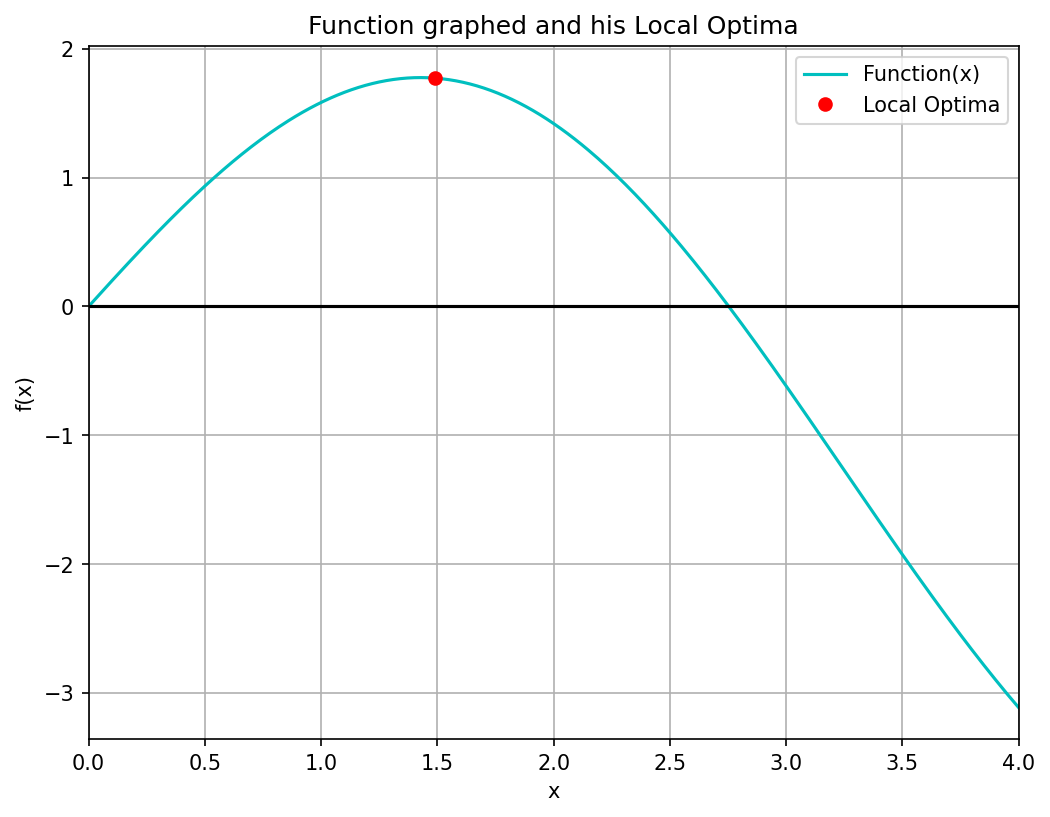

In [6]:
f = lambda x: 2 * np.sin(x) - x**2 / 10
x0 = 0.0; x1 = 1.0; x2 = 4.0
parabolic_interpolation(f, x0, x1, x2, 1e-2, 1e-1, 1, 19)

In [7]:
def derivative(fx, x, h = 1e-2):
    return (fx(x + h) - fx(x - h)) / (2 * h)
def second_derivative(fx, x, h = 1e-2):
    return (fx(x + h) - 2 * fx(x) + fx(x - h)) / h**2
def newthons_optimization(fx, xi, n, epsilon):
    """Adaptation of the Newton-Raphson method for finding extrema of f(x)."""
    h = 1e-2
    xold = None
    for i in range(n):
        x_opt = xi - derivative(fx, xi, h) / second_derivative(fx, xi, h)
        print(f"iteration {i + 1}, x = {x_opt}, f(x) = {fx(x_opt)}, second derivative value = {second_derivative(fx, xi, h)}") 
        # Use the second derivative to determine whether the critical point is a maximum or a minimum.
        if xold is not None:
            error = np.abs((x_opt - xold) / x_opt)
            if error < epsilon:
                print(f"Converges in iteration {i + 1}, relative error = {error}")
                break
        xi = x_opt
        xold = x_opt
        

In [8]:
f = lambda x: 2 * np.sin(x) - x**2 / 10
xi = 2.5
newthons_optimization(f, xi, 15, 1e-2)

iteration 1, x = 0.99508992240151, f(x) = 1.5785954562049178, second derivative value = -1.396934313706577
iteration 2, x = 1.4690023154874985, f(x) = 1.7738501435040575, second derivative value = -1.8776018714850018
iteration 3, x = 1.4276404284850237, f(x) = 1.775725644583221, second derivative value = -2.1896303434587594
iteration 4, x = 1.4275495966842553, f(x) = 1.7757256531422263, second derivative value = -2.179524867764737
Converges in iteration 4, relative error = 6.362777235858069e-05


# Extra (Brentt Method)

In [9]:
def parabolic_candidate(f, v, w, x):
    p = (w - x)**2 * (f(x) - f(v)) + (v - x)**2 * (f(w) - f(x))
    q = (w - x) * (f(x) - f(v)) + (v - x) * (f(w) - f(x))
    if np.isclose(q, 0, atol=1e-8):
        return None
    else:
        return x + 0.5 * p / q
        
def golden_section_candidate(f, a, b, x):
    m = (a + b) / 2
    tau = (3 - np.sqrt(5)) / 2
    if x >= m:
        return x  + tau * (a - x)
    else:
        return x  + tau * (b - x)
def brent_method(f, a, b, v: float, w: float, x: float, n, op: bool = True, epsilon: float = 1e-2):
    for i in range(n):
        u_spi = parabolic_candidate(f, v, w, x)
        
        if u_spi is not None and (a < u_spi < b) and (abs(u_spi - x) < (b - a) / 2):
            use_parabolic_step = True
        else:
            use_parabolic_step = False
            
        if use_parabolic_step:
            u = u_spi
            print("SPI step")
        else:
            u = golden_section_candidate(f, a, b, x)
            print("GSS step")
            
        fu = f(u)
        fx = f(x)
        fw = f(w)
        fv = f(v)
        if op:  # minimize
            better = fu < fx
        else:   # maximize
            better = fu > fx
        if better:
            if u < x:
                b = x
            else:
                a = x
            v = w
            w = x
            x = u
        else:
            if u < x:
                a = u
            else:
                b = u
                
            if fu <= fw or w == x:
                v = w
                w = u
            elif fu <= fv or v == x or v == w:
                v = u
        if abs(b - a) < epsilon:
            print(f"Converged in {i+1} iterations")
            break
    return x


In [10]:
f = lambda x: (x-2)**2
a = 0
b = 5
v = 1
w = 3
x = 2.5
brent_method(f, a, b, v, w, x, 10)

SPI step
SPI step
GSS step
GSS step
GSS step
GSS step
GSS step
GSS step
Converged in 8 iterations


2.0

# Multi-Dimensional


In [11]:
x_range = np.random.uniform(0, 100, 5)
def random_optimization_max(f, xi, xf, yi, yf, n):
    """Random Search Brute-force sampling of function at random points"""
    x_range = np.random.uniform(xi, xf, n)
    y_range = np.random.uniform(yi, yf, n)
    eva = f(x_range, y_range)
    max_index = np.argmax(eva)
    print(f"max in function {max(eva)}, x = {x_range[max_index]}, y = {y_range[max_index]}")

In [12]:
f = lambda x, y: y - x - 2 * x**2 - 2 * x * y - y**2
n = 1000
random_optimization_max(f, -2, 2, 1, 3, n)

max in function 1.2416972972007172, x = -1.05147495375526, y = 1.4762883064355634


Example 4
>Develop a graphical solution for the following problem:
>$$maximize \quad Z  = 150x_1 + 175x_2$$
>subject to
>$$7x_1+11x_2 \leq 77$$
>$$10x_1 + 8x_2 \leq 80$$
>$$0\leq x_1 \leq 9$$
>$$0 \leq x_2 \leq 6$$

(np.float64(4.902759806114329), np.float64(3.838390691565774), np.float64(1407.1323419411597))


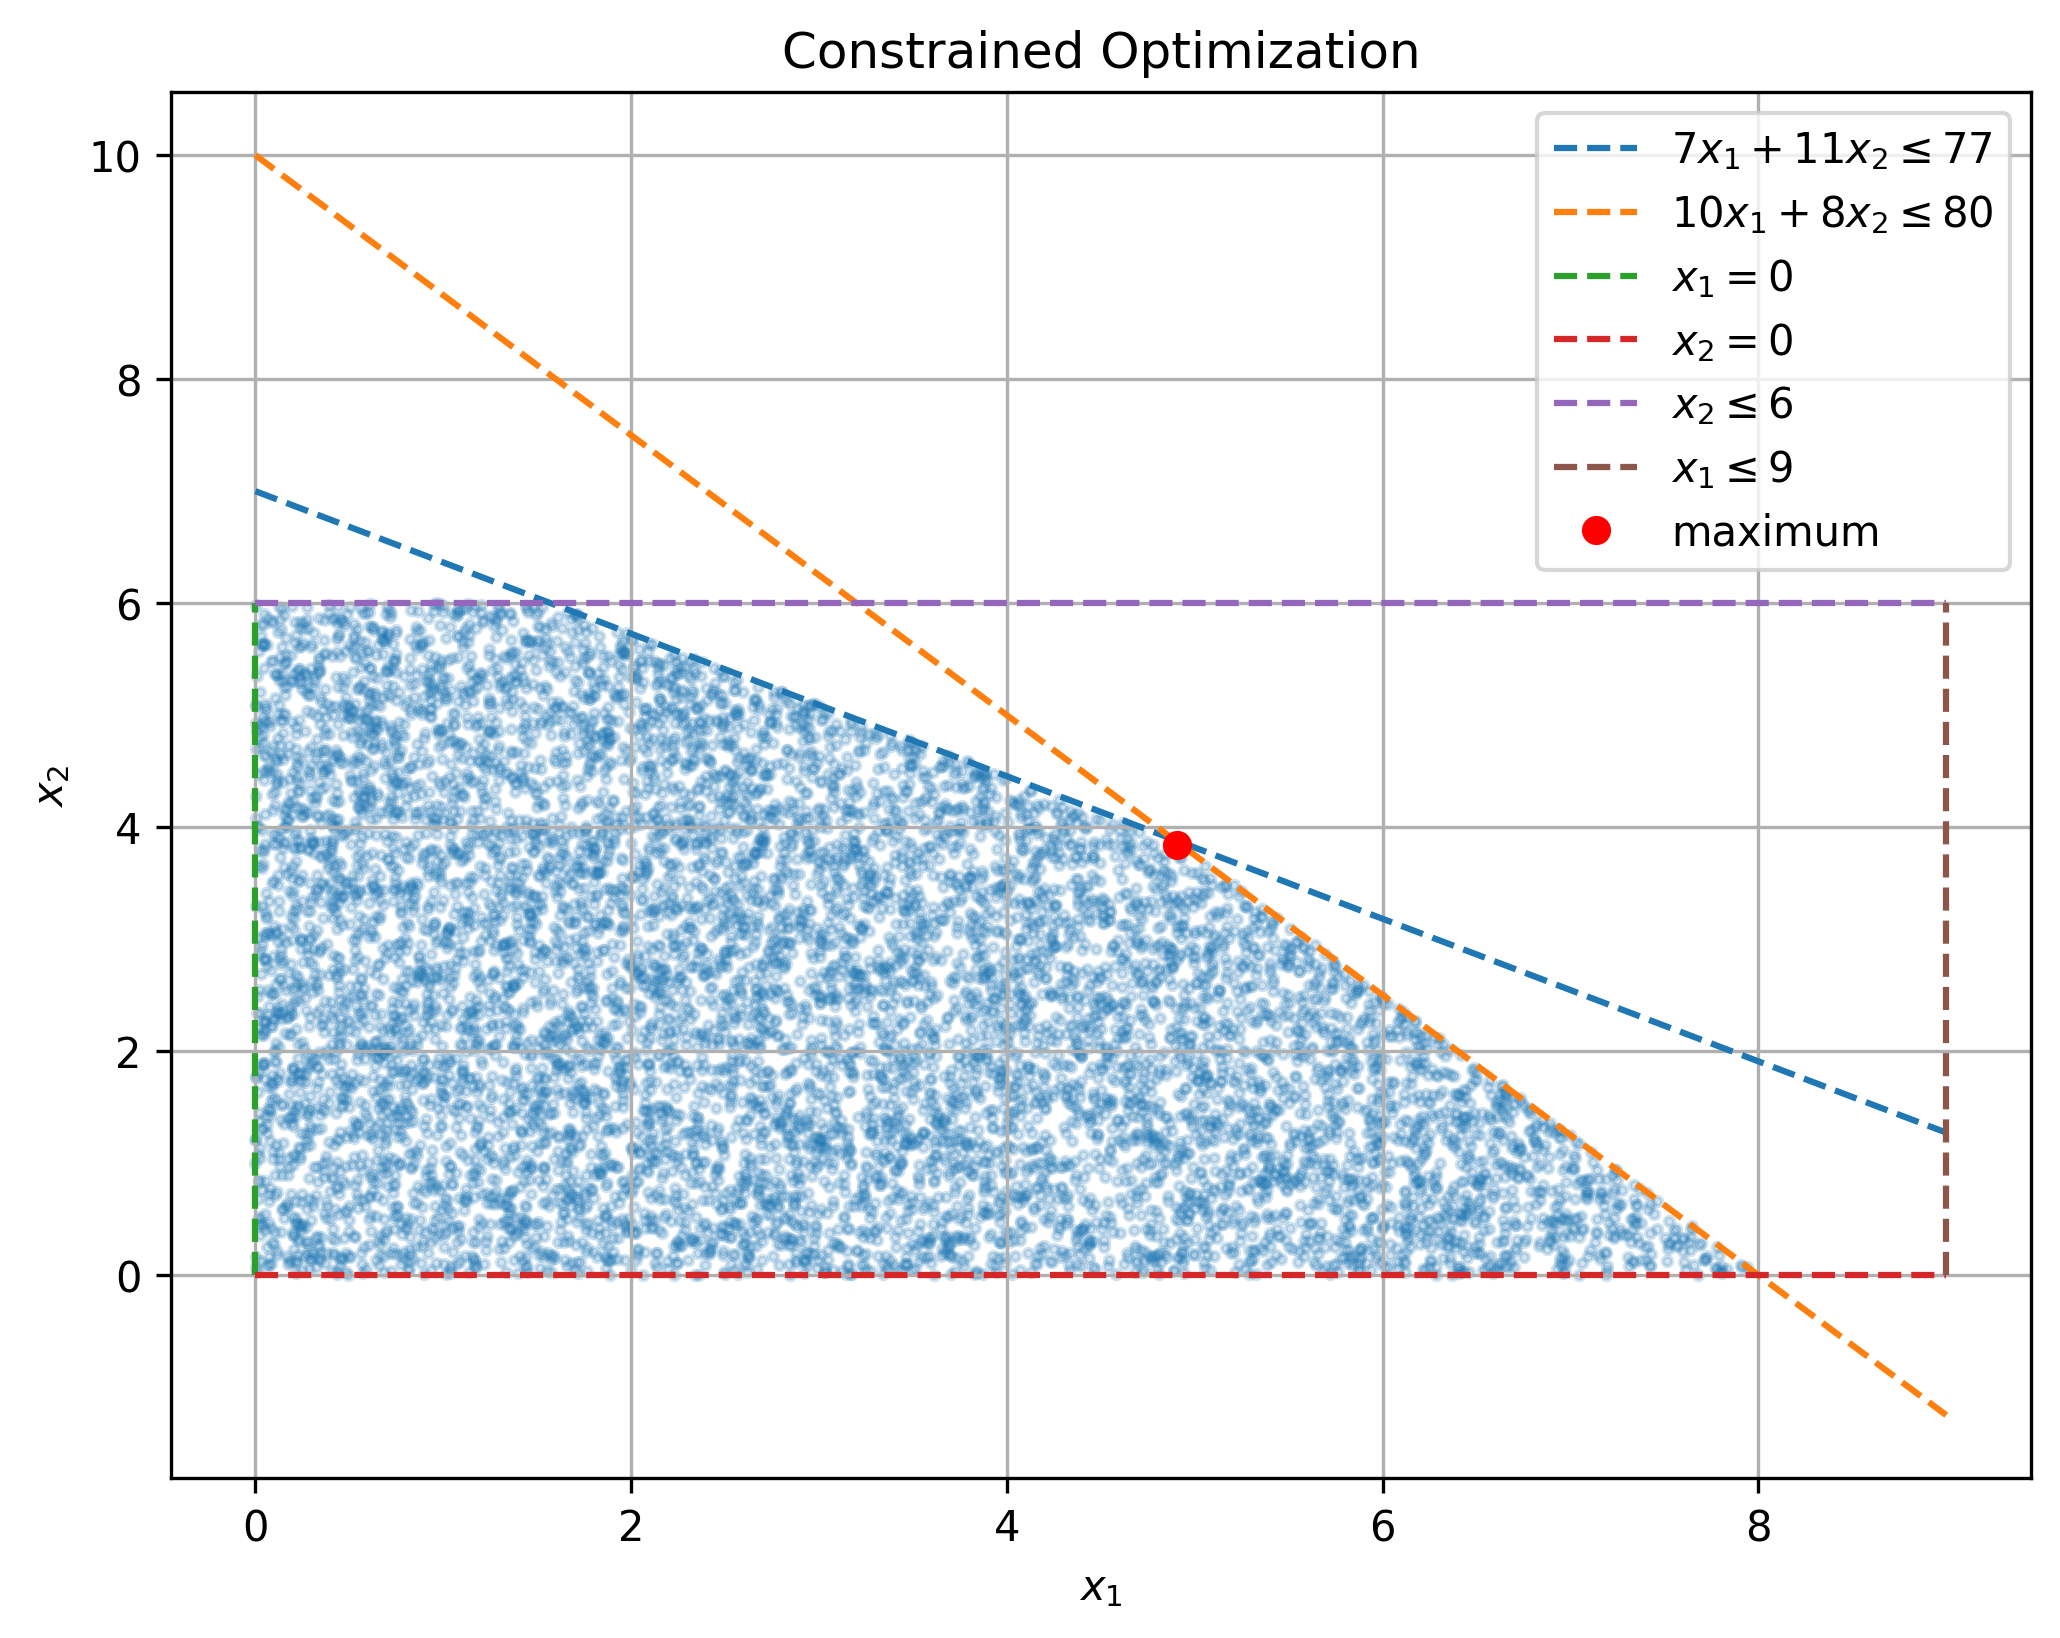

In [13]:
n = 15000
z = lambda x_1, x_2: 150 * x_1 + 175 * x_2
x1_range = np.random.uniform(0, 9, n)
x2_range = np.random.uniform(0, 6, n)
feasible_points = [
    (x1, x2, z(x1, x2))
    for x1, x2 in zip(x1_range, x2_range)
    if 7*x1 + 11*x2 <= 77
    and 10*x1 + 8*x2 <= 80
]
best = max(feasible_points, key = lambda p: p[2])
print(best)
constraint_1 = lambda x1: (77 - 7*x1)/11
constraint_2 = lambda x1: (80 - 10*x1)/8
dx = 0.5
x1 = np.arange(0.0, 9.0 + dx, dx)
x2 = np.arange(0.0, 6.0 + dx, dx)
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=300)
ax.scatter(
    [p[0] for p in feasible_points],
    [p[1] for p in feasible_points],
    s=5,
    alpha=0.2
)
ax.plot(x1, constraint_1(x1), '--', label=r"$7x_1+11x_2 \leq 77$")
ax.plot(x1, constraint_2(x1), '--', label=r"$10x_1 + 8x_2 \leq 80$")
ax.plot(np.zeros(len(x2)), x2,'--', label=r"$x_1 = 0$")
ax.plot(x1, np.zeros(len(x1)),'--', label=r"$x_2 = 0$")
ax.plot(x1, np.ones(len(x1))*6,'--', label=r"$x_2 \leq 6$")
ax.plot(np.ones(len(x2))*9, x2,'--', label=r"$x_1 \leq 9$")
ax.plot(best[0], best[1], 'ro', label="maximum")
ax.set_title("Constrained Optimization")
ax.set_ylabel(r"$x_2$")
ax.set_xlabel(r"$x_1$")
ax.legend()
ax.grid()
fig.savefig('Images/Constrained Optimization.png', dpi=300, bbox_inches='tight')

Estimated minimum at (0.36180339887498947, 1.516812626295337)
Estimated minimum at (0.38541019662496845, 1.504510636582868)
Estimated minimum at (0.4, 1.5026548245743667)
Estimated minimum at (0.3909830056250526, 1.5033104459350146)
Estimated minimum at (0.3965558146251367, 1.5027211569092649)
Estimated minimum at (0.4, 1.5026548245743667)
Converges in iteration 6, maximum in: (0.4, 1.5026548245743667) 
 interval size: 0.011145618000168223 and relative approximate error: 0.008610463437158239


(np.float64(0.4), np.float64(1.5026548245743667))

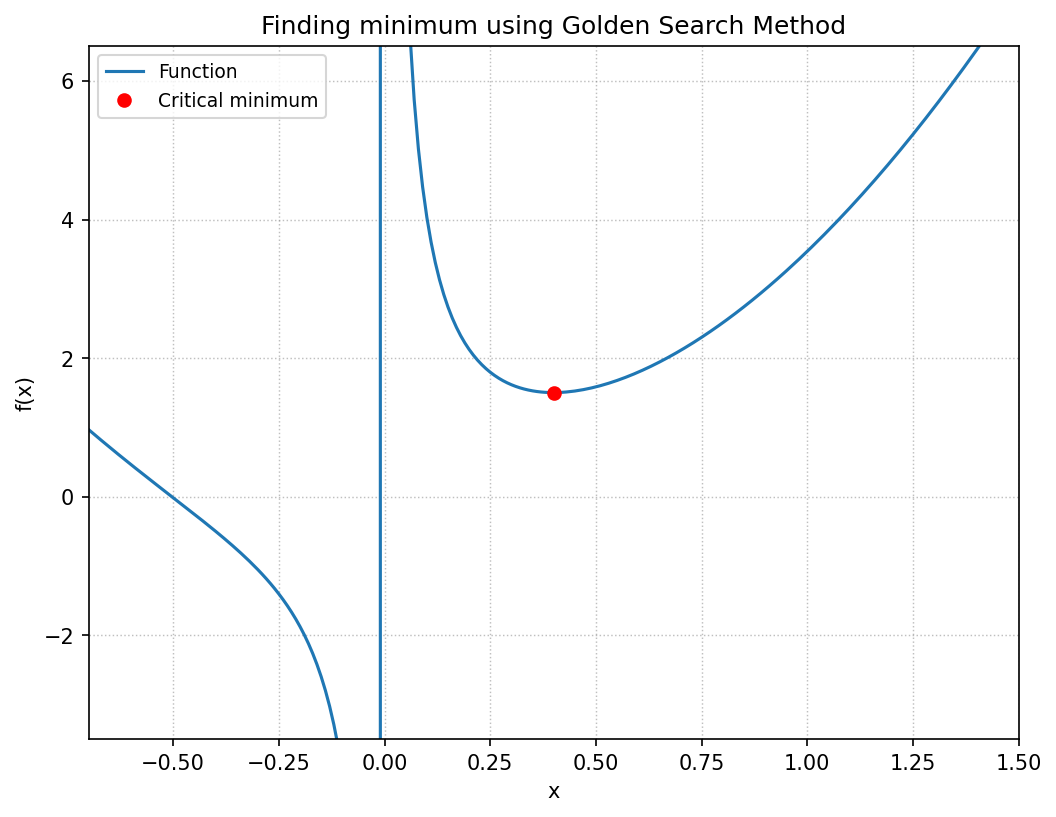

In [14]:
h = lambda r: 0.2 / (np.pi * r**2)
A = lambda r: np.pi * r**2 + 2 * np.pi * r * h(r)
rl = 0.3
ru = 0.5
golden_section_search(A, rl, ru, 0, n = 100)

# Curve Fitting


In [15]:
def polyfit(x_data, y_data, order):
    aorder = order + 1
    b = np.array(y_data)
    A = np.ones((len(b), aorder))
    for i in range(1, aorder):
        A[:, i] = np.array(x_data) ** i
    coef, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)
    print(coef)
    regression = lambda x: sum(c * x**i for i, c in enumerate(coef))
    # Graph
    fig, ax = plt.subplots(1, 1, figsize=(8,6), dpi = 300)

    x0 = x_data[0] - 1; xf = x_data[-1] + 1; dx = 1e-2

    x = np.arange(x0, xf + dx, dx)
    regression = regression(x)
    
    
    ax.plot(x_data, y_data, '^', label='reported data (experimental)')
    ax.plot(x, regression, label=f"Regression {order} Order")
    ax.legend()
    ax.grid()
    
    print("Coefficients:", coef)
    print("Residual sum of squares:", residuals)
    print("Rank:", rank)
    print("Singular values:", s)

[  1.18901515  19.35911797 -14.72660985   4.89488636  -0.44232955]
Coefficients: [  1.18901515  19.35911797 -14.72660985   4.89488636  -0.44232955]
Residual sum of squares: [69.11143398]
Rank: 5
Singular values: [2.84501167e+03 5.41537874e+01 3.80486306e+00 1.17539864e+00
 3.57564143e-01]


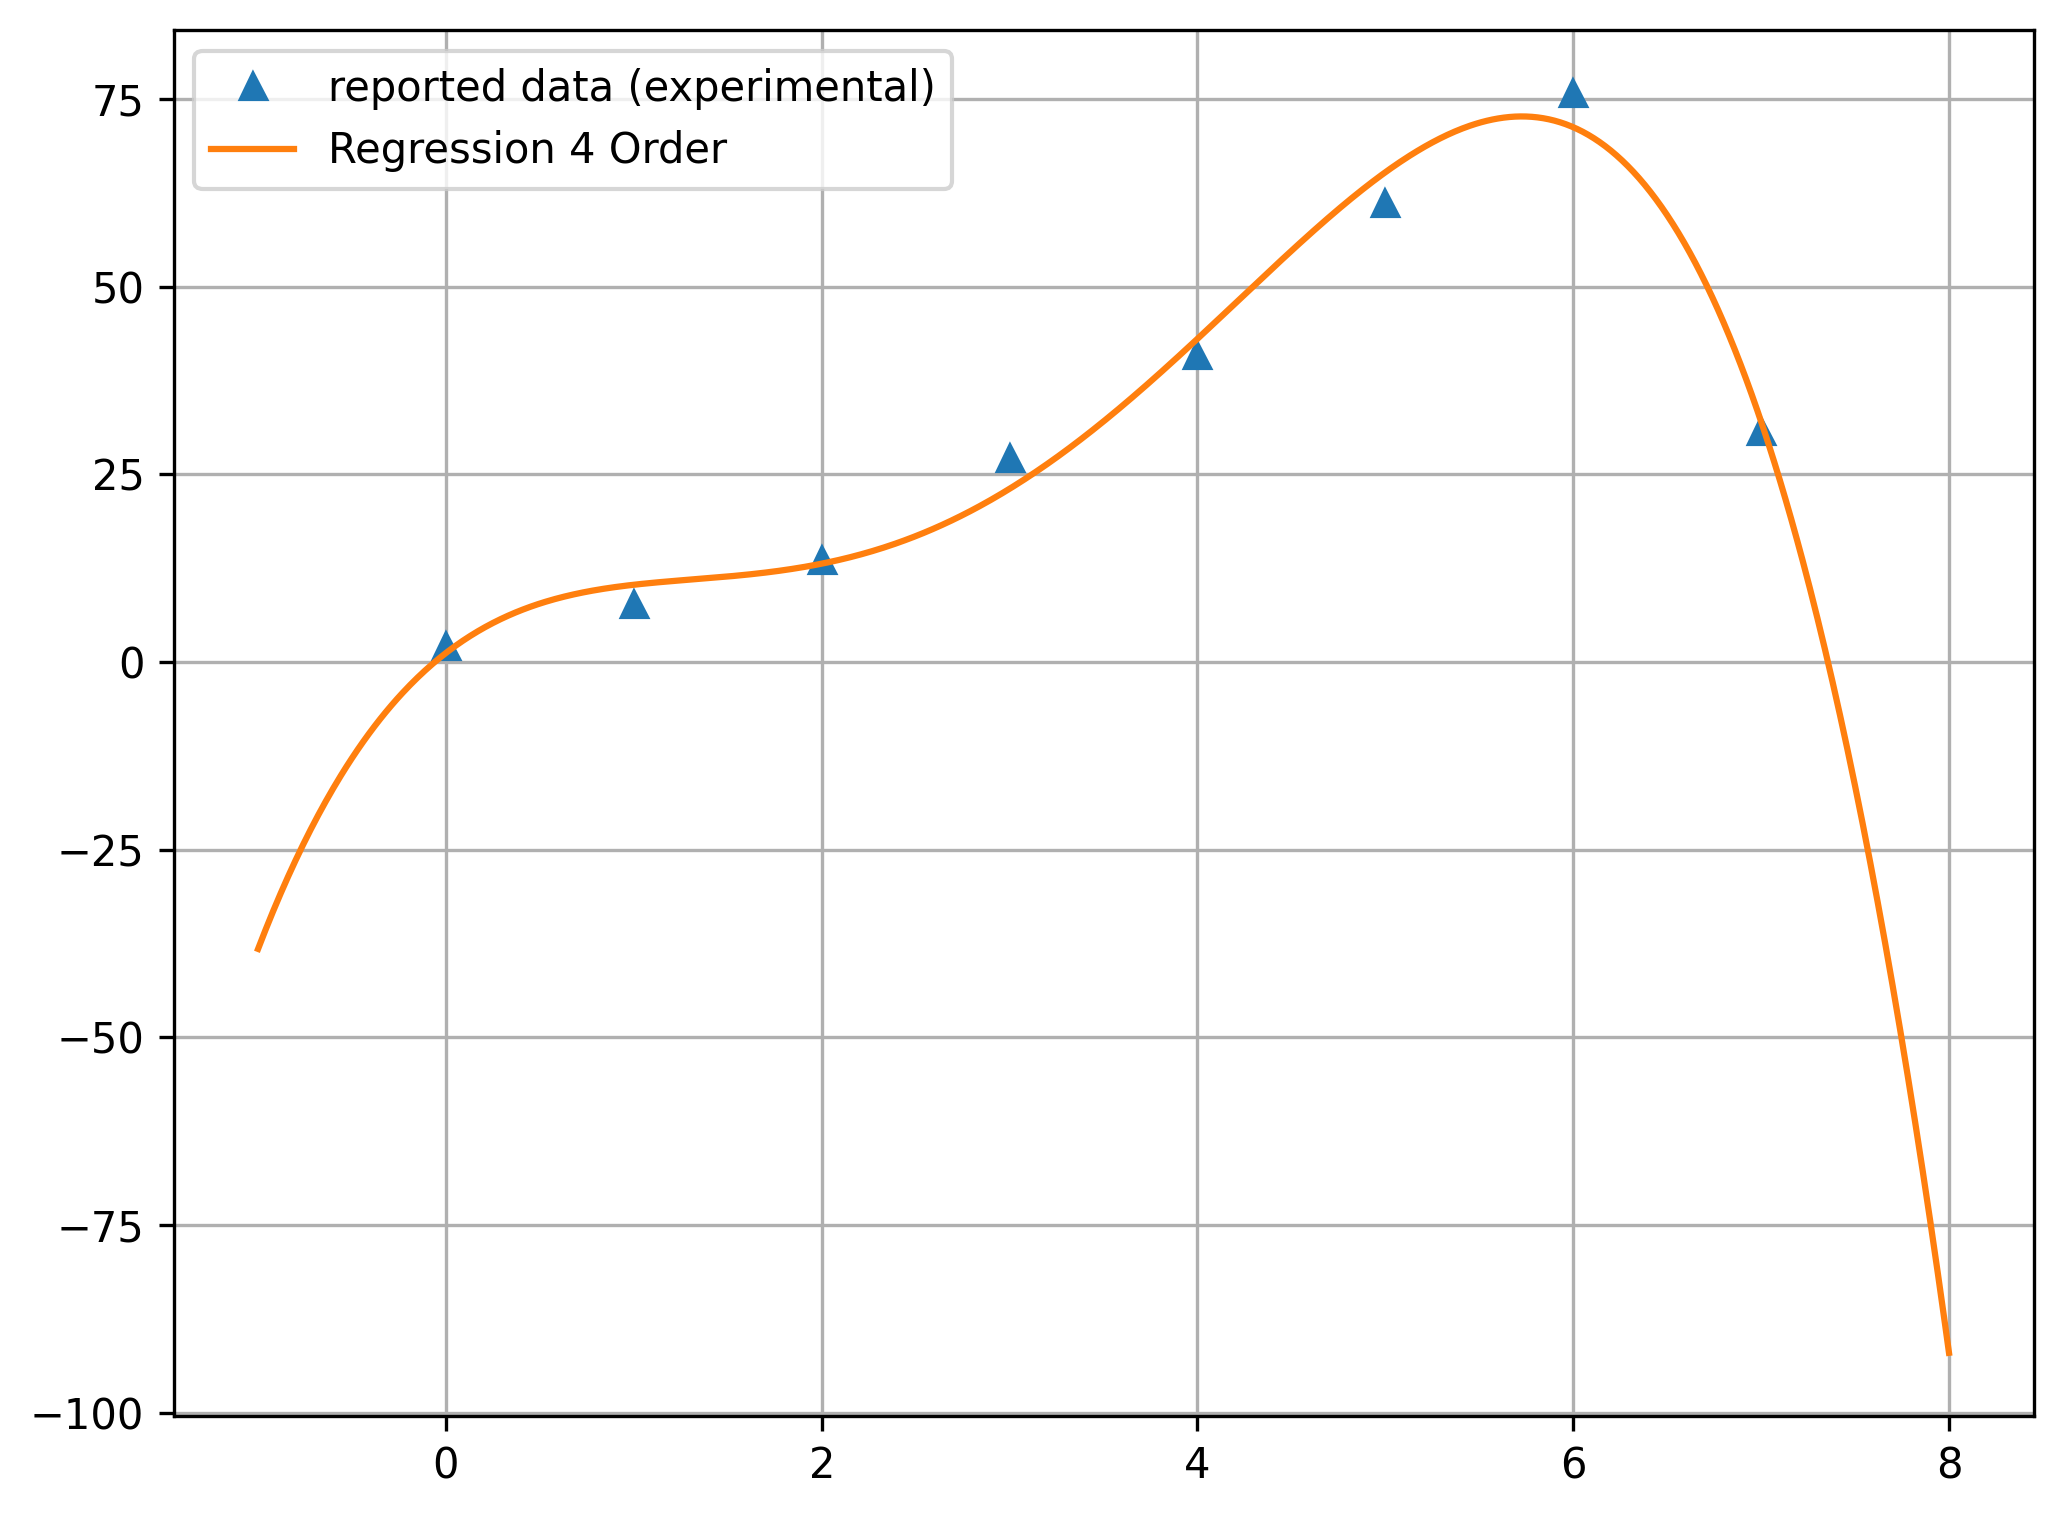

In [16]:
x = [x for x in range(8)]
y = [2.1, 7.7, 13.6, 27.2, 40.9, 61.1, 75.8, 30.7]
np.sum(y)
polyfit(x, y, 4)


In [17]:
def linear_interpolation(f, x0, x1, x_est):
    
    interpolating = lambda x: f(x0) + (f(x1) - f(x0)) / (x1 - x0) * (x - x0)
    real_value = f(x_est)
    interp_value = interpolating(x_est)
    
    error = abs(
        (real_value - interp_value)
        / real_value
    ) * 100
    # Graphical Insight
    xi = x0; xf = x1 + 0.5; dx = 1e-2
    x = np.arange(xi, xf + dx, dx)
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.plot(x, f(x), label="Real Function")
    ax.plot(x, interpolating(x), '-.', label="Linear Interpolation")
    ax.plot(x_est, f(x_est), 'ro', label="Real Value")
    ax.plot(x_est, interp_value, 'bo', label="Approximate Value")
    ax.grid()
    ax.legend()
    ax.set_xlim([xi, xf])
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.set_title("Linear Interpolation")
    
    fig.savefig('Images/linear_interpolation.png', bbox_inches="tight", dpi=300)

    
    return interp_value, error

(np.float64(0.358351893845611), np.float64(48.30074998557687))

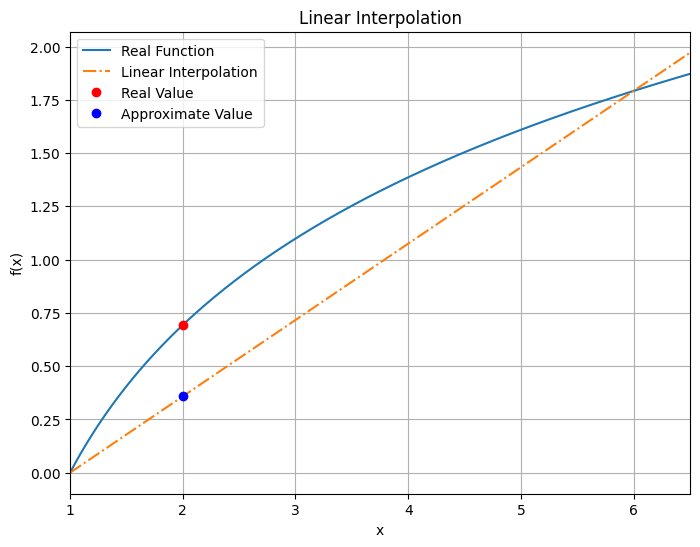

In [18]:
f = lambda x: np.log(x)
x0 = 1.0; x1 = 6.0; x_est = 2
linear_interpolation(f, x0, x1, x_est)

In [19]:
def quadratic_interpolation(x_data, y_data, x_est):
    x = x_data
    y = y_data
    b0 = y[0]
    b1 = (y[1] - y[0]) / (x[1] - x[0])
    b2 = ((y[2] - y[1]) / (x[2] -x[1]) - b1) / (x[2] - x[0])
    f = lambda alp: b0 + b1 * (alp - x[0]) + b2 * (alp - x[0]) * (alp - x[1])
    print(f"approximate value: {f(x_est)}")
    return f

approximate value: 1.0279421999999998


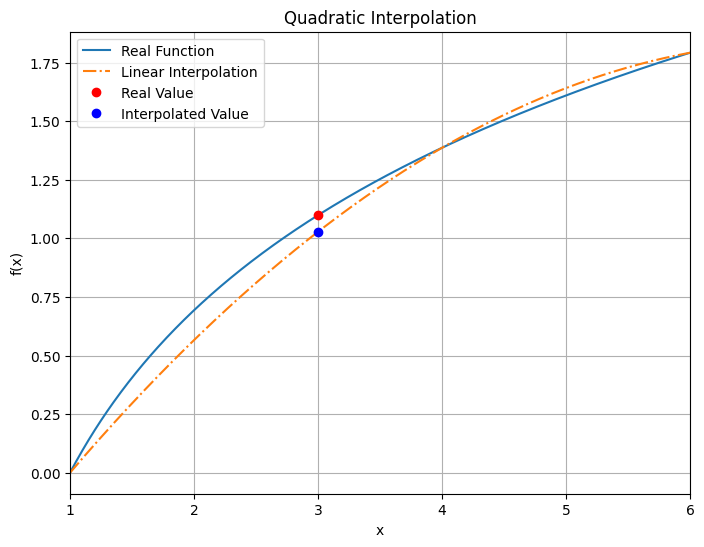

In [20]:
x_data = [1, 4, 6]
y_data = [0, 1.386294, 1.791759]
x_est = 3
interpolating = quadratic_interpolation(x_data, y_data, 3)
f = lambda x: np.log(x)
xi = x_data[0]; xf = x_data[-1]; dx = 1e-2
x = np.arange(xi, xf + dx, dx)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(x, f(x), label="Real Function")
ax.plot(x, interpolating(x), '-.', label="Linear Interpolation")
ax.plot(x_est, f(x_est), 'ro', label="Real Value")
ax.plot(x_est, interpolating(3), 'bo', label="Interpolated Value")

ax.grid()
ax.legend()
ax.set_xlim([xi, xf])
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("Quadratic Interpolation")
    
fig.savefig('Images/linear_interpolation.png', bbox_inches="tight", dpi=300)

In [21]:
def divided_difference_table(n, y_data):
    table = np.zeros((n, n))
    table[:,0] = y_data
    for j in range(1,n):
        for i in range(j,n):
            table[i,j] = (
                table[i,j-1]
                - table[i-1,j-1]
            ) / (
                x_data[i]
                - x_data[i-j]
            )
    print(table)
    return table
def print_newton_polynomial(x_data, coef):
    terms = []

    for i, b in enumerate(coef):
        term = f"{b:.6f}"

        for j in range(i):
            term += f"(x-{x_data[j]})"

        terms.append(term)
    polynomial = " + ".join(terms)
    print("P(x) =")
    print(polynomial)
    return polynomial
def general_newton_interpolating(x_data, y_data, x_est):
    x = x_est
    n = len(x_data)
    table = divided_difference_table(n, y_data)
    coef = np.diag(table)
    def P(x):

        result = 0
        for i in range(n):

            term = 1

            for j in range(i):
                term *= (x - x_data[j])

            result += coef[i] * term

        return result

    return P, coef
    


In [22]:
x_data = [1, 4, 6, 5]
y_data = [0, 1.386294, 1.791759, 1.609438]
x_est = 2
P, coef = general_newton_interpolating(x_data, y_data, x_est)
polynomial = print_newton_polynomial(x_data, coef)
P(2)

[[ 0.         0.         0.         0.       ]
 [ 1.386294   0.462098   0.         0.       ]
 [ 1.791759   0.2027325 -0.0518731  0.       ]
 [ 1.609438   0.182321  -0.0204115  0.0078654]]
P(x) =
0.000000 + 0.462098(x-1) + -0.051873(x-1)(x-4) + 0.007865(x-1)(x-4)(x-6)


np.float64(0.6287674)

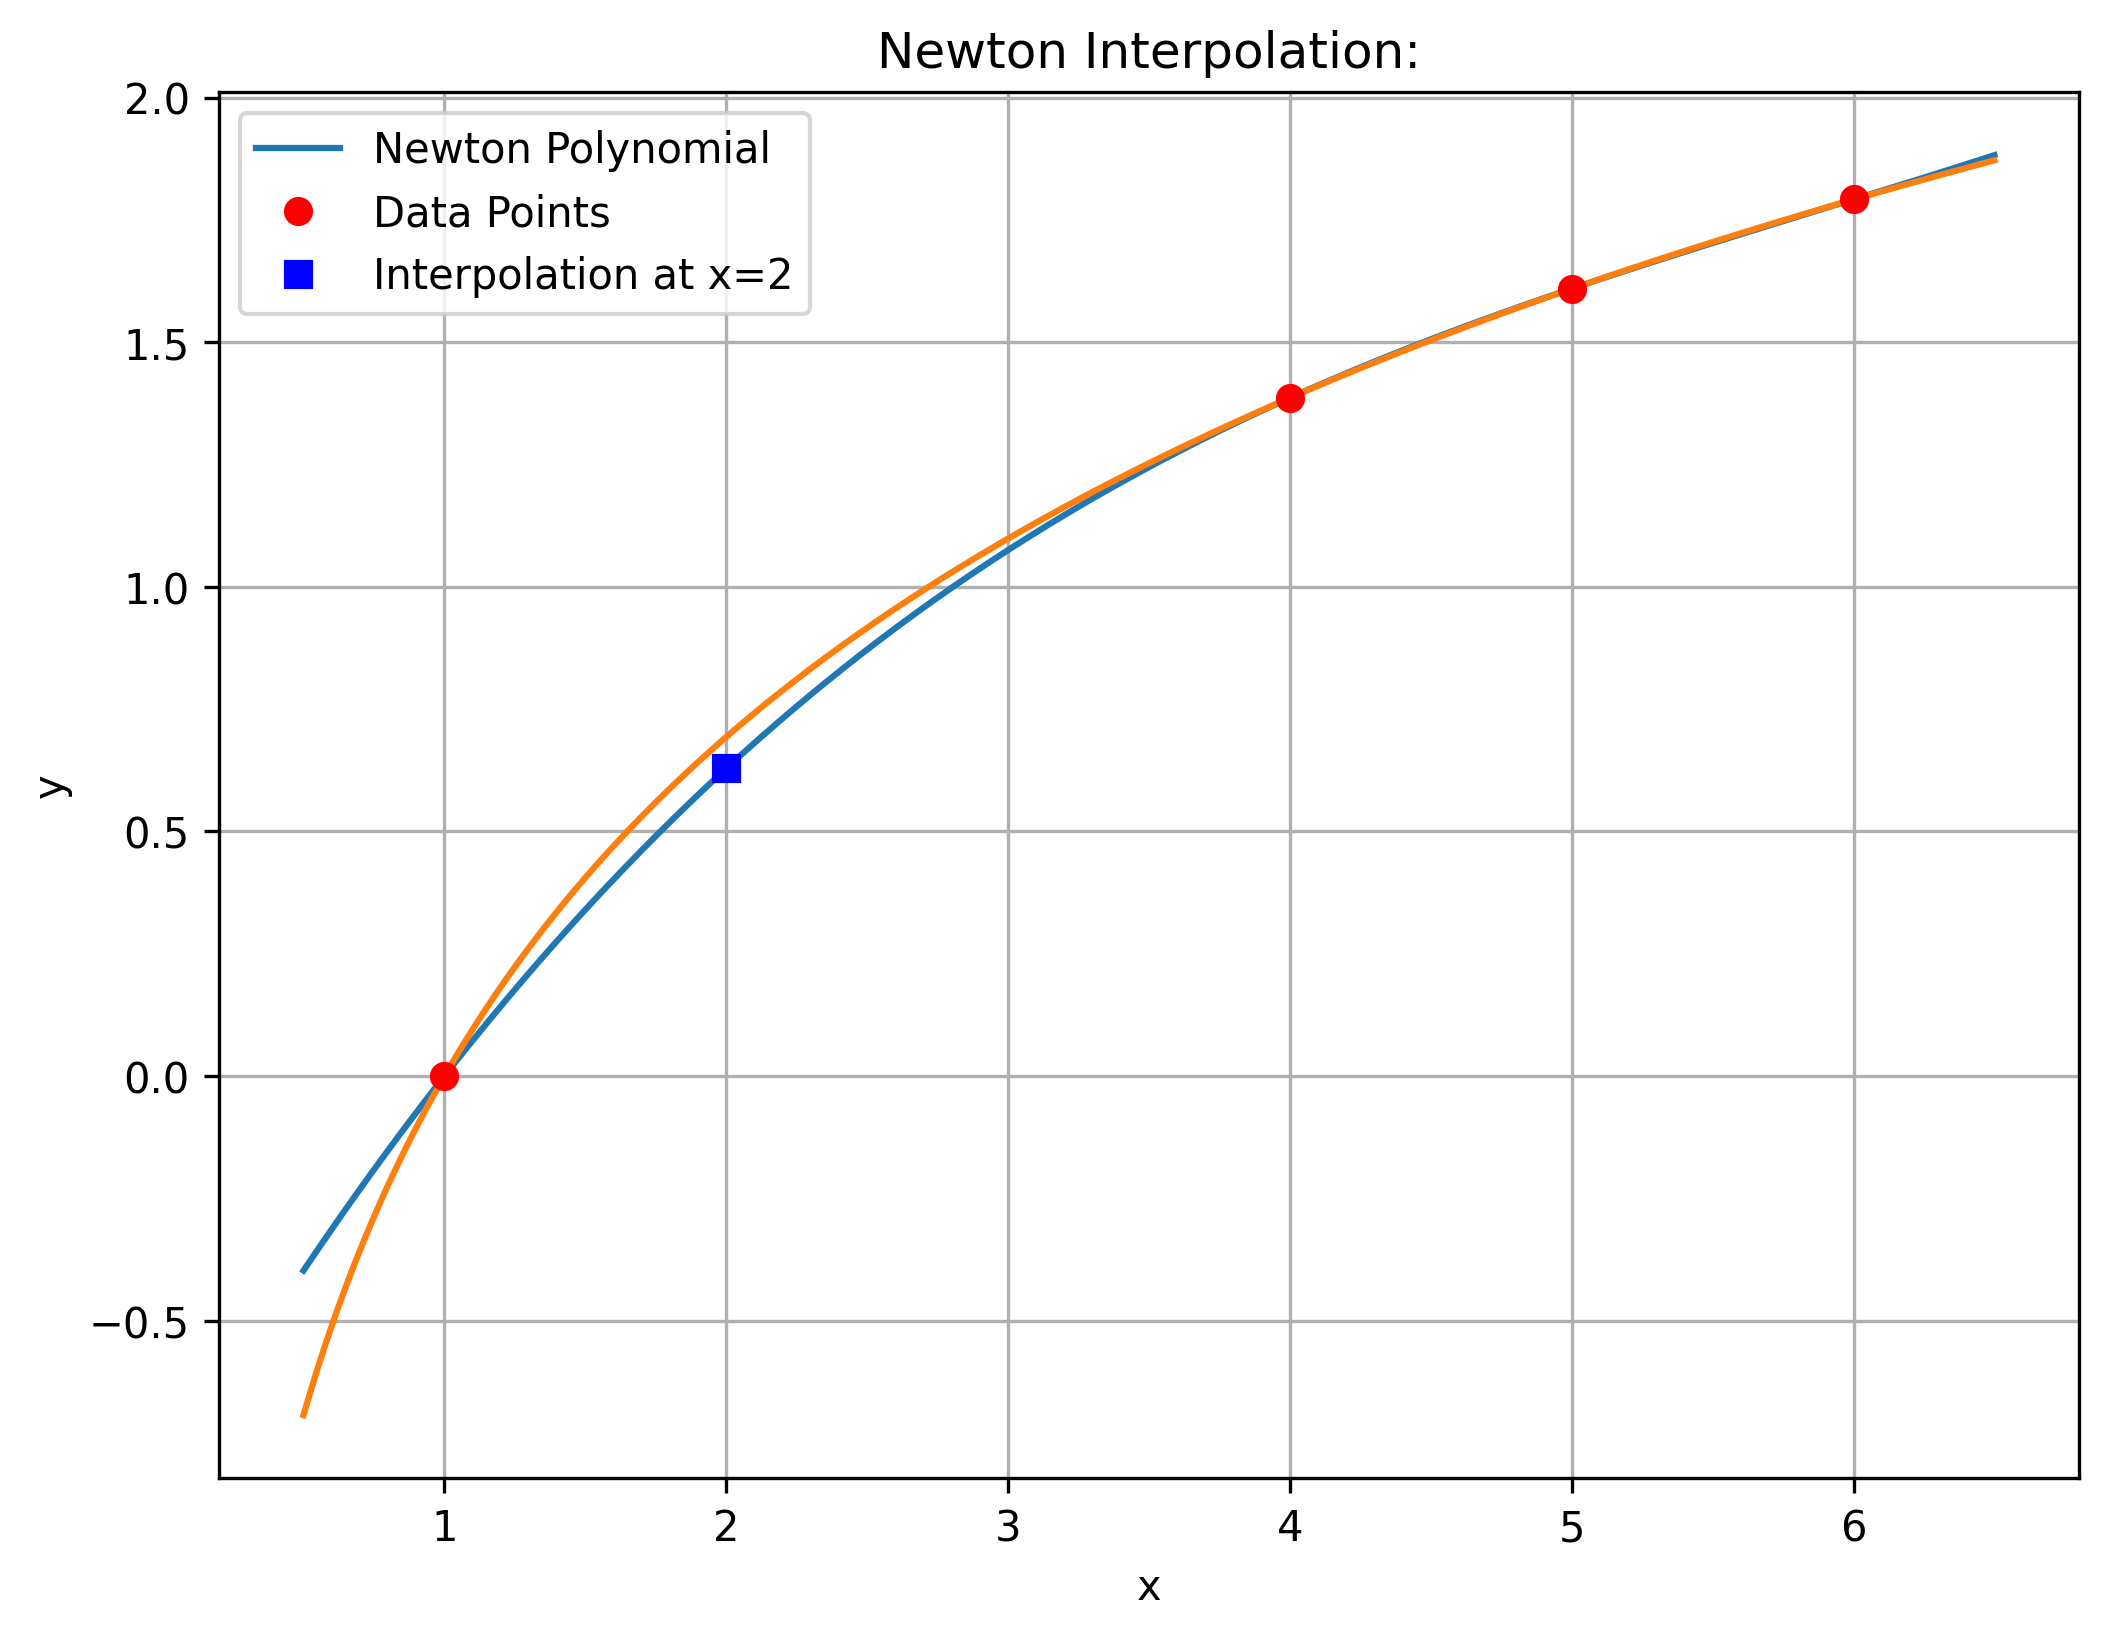

In [23]:
fig, ax = plt.subplots(figsize=(8,6), dpi=300)

x = np.linspace(
    min(x_data)-0.5,
    max(x_data)+0.5,
    500
)

ax.plot(
    x,
    P(x),
    label="Newton Polynomial"
)
ln = lambda x: np.log(x)
ax.plot(x, ln(x))
ax.plot(
    x_data,
    y_data,
    'ro',
    label="Data Points"
)

ax.plot(
    x_est,
    P(x_est),
    'bs',
    label=f"Interpolation at x={x_est}"
)

ax.grid()
ax.legend()

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_title(f"Newton Interpolation:")

plt.show()

In [24]:
def lagrange_interpolating(x, x_data, y_data):
    
    if len(x_data) != len(y_data):
        raise ValueError("x_data and y_data must have same length")
    n = len(y_data)
    result = 0
    for i in range(n):
        term = 1
        for j in range(n):
             if j != i:
                 term *= (x - x_data[j]) / (x_data[i] - x_data[j])
        result += term * y_data[i]
        
    
    return result


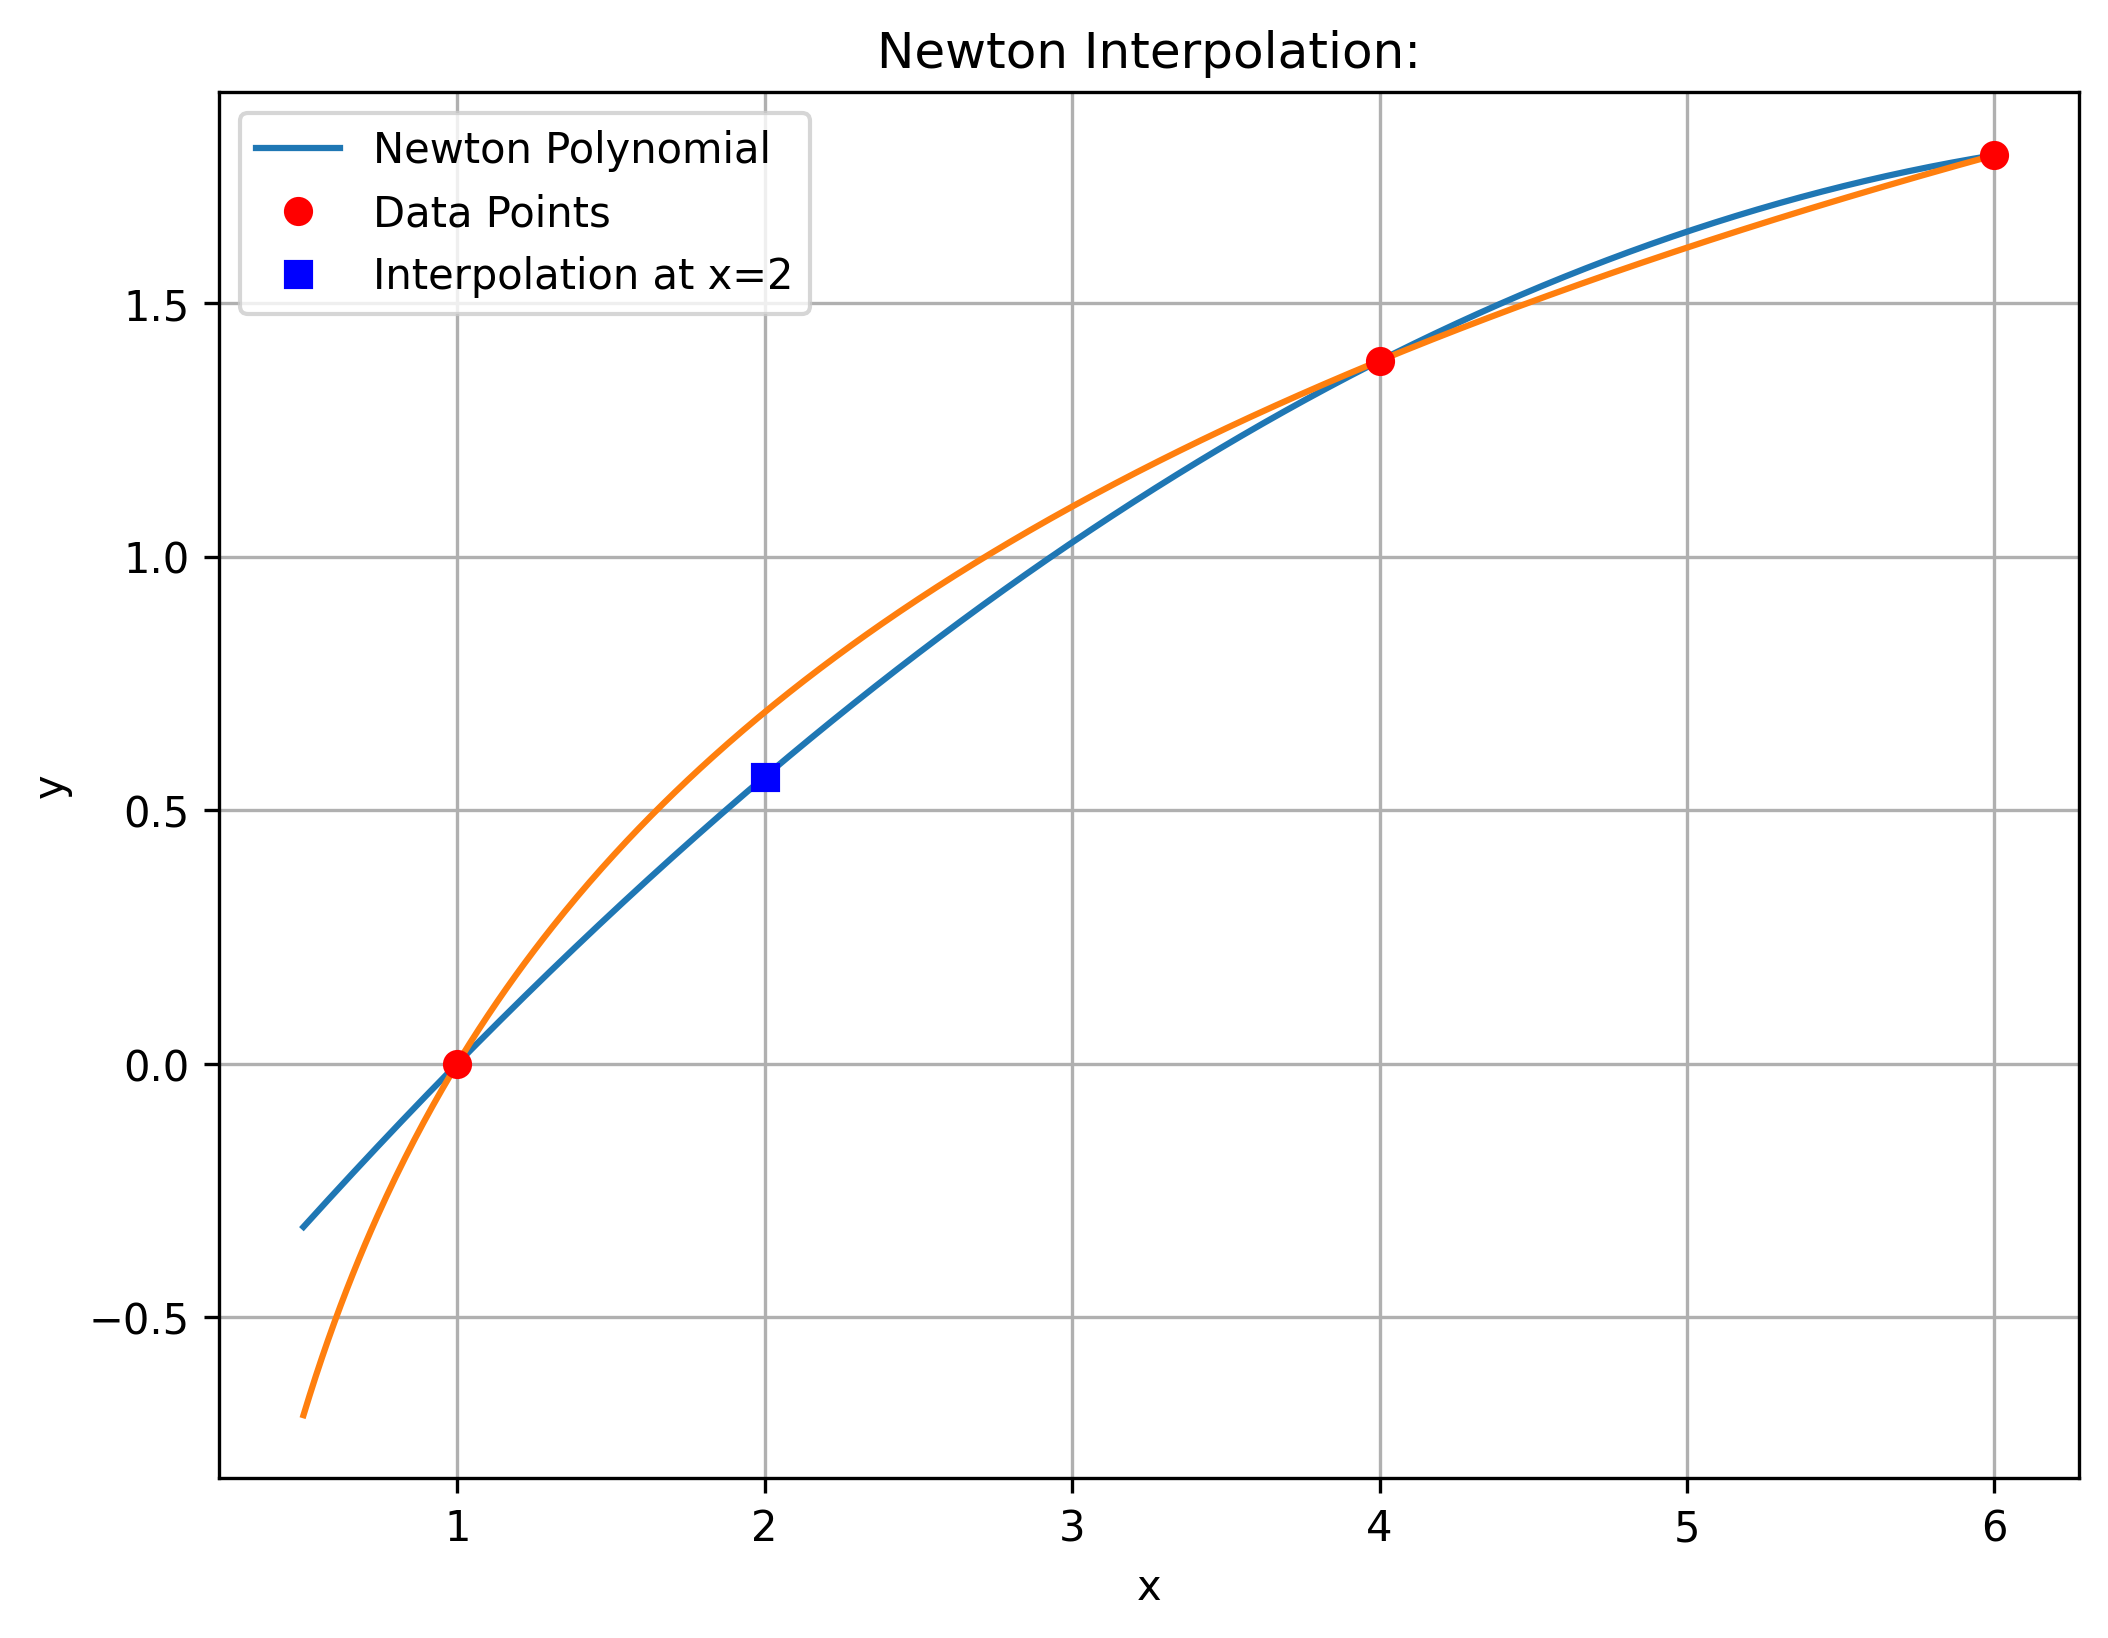

In [25]:
x_data = [1, 4, 6]
y_data = [0, 1.386294, 1.791759]
x_est = 2
x = np.arange(0.5, 6.0 + 1e-2, 1e-2)
f = lagrange_interpolating(x, x_data, y_data)
interpolated = lagrange_interpolating(x_est, x_data, y_data)
fig, ax = plt.subplots(figsize=(8,6), dpi=300)

ax.plot(
    x,
    f,
    label="Newton Polynomial"
)
ln = lambda x: np.log(x)
ax.plot(x, ln(x))
ax.plot(
    x_data,
    y_data,
    'ro',
    label="Data Points"
)

ax.plot(
    x_est,
    interpolated,
    'bs',
    label=f"Interpolation at x={x_est}"
)

ax.grid()
ax.legend()

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_title(f"Newton Interpolation:")

plt.show()

In [26]:
N = 10
A0 = 1.7
omega = 4.189
theta = 1.0472
y = lambda t: 1.7 + np.cos(omega * t + theta)
t0 = 0; tf = 1.35; dt = 0.15
t = np.arange(t0, tf, dt)
y = y(t)

# Matirx
A = np.array([[N, np.sum(np.cos(omega * t)), np.sum(np.sin(omega * t))], 
            [np.sum(np.cos(omega * t)), np.sum(np.cos(omega * t)**2), np.sum(np.cos(omega * t) * np.sin(omega * t))],
            [np.sum(np.sin(omega * t)), np.sum(np.cos(omega * t) * np.sin(omega * t)), np.sum(np.sin(omega * t)**2)]])
b = np.array([[np.sum(y)],
            [np.sum(y * np.cos(omega * t))],
            [np.sum(y * np.sin(omega * t))]])

a0, a1, b0 = np.linalg.solve(A, b)
print(a0, a1, b0)

[1.7] [0.49999788] [-0.86602663]


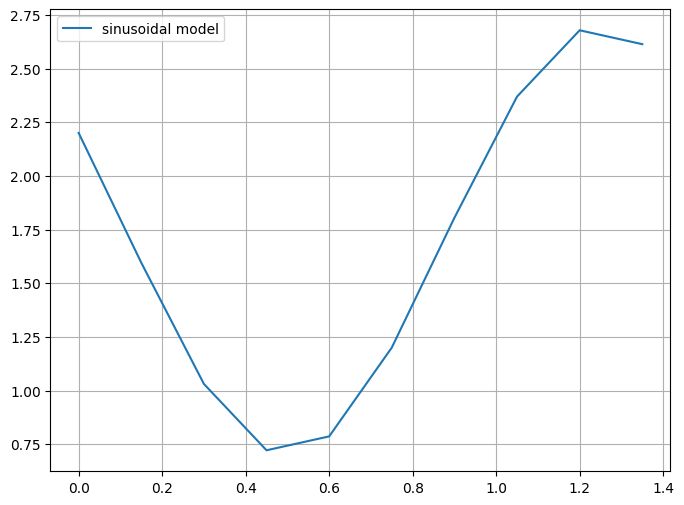

In [27]:
yi = lambda t: a0 + a1 * np.cos(omega * t) + b0 * np.sin(omega * t)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(t, yi(t), label='sinusoidal model')
ax.legend()
ax.grid()

In [28]:
A = np.column_stack([
    np.ones(len(t)),
    np.cos(omega*t),
    np.sin(omega*t)
])

coef, residuals, rank, s = np.linalg.lstsq(
    A,
    y,
    rcond=None
)

print(coef)

[ 1.7         0.49999788 -0.86602663]


In [29]:
def least_squares(x_data, y_data, order):
    aorder = order + 1
    b = y_data
    A = np.column_stack([np.array(x_data)**i 
                         for i in range(order)])
    coef, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)
    regression = lambda x: sum(c * x**i for i, c in enumerate(coef))
    # Graph
    fig, ax = plt.subplots(1, 1, figsize=(8,6), dpi = 300)

    x0 = x_data[0] - 1; xf = x_data[-1] + 1; dx = 1e-2

    x = np.arange(x0, xf + dx, dx)
    regression = regression(x)
    
    
    ax.plot(x_data, y_data, '^', label='reported data (experimental)')
    ax.plot(x, regression, label=f"Regression {order} Order")
    ax.legend()
    ax.grid()
    
    print("Coefficients:", coef)
    print("Residual sum of squares:", residuals)
    print("Rank:", rank)
    print("Singular values:", s)

Coefficients: [2.25079365 3.3994709  1.29126984 0.07592593]
Residual sum of squares: [3.37301587]
Rank: 4
Singular values: [146.69715406   5.74370934   1.3230218    0.4521155 ]


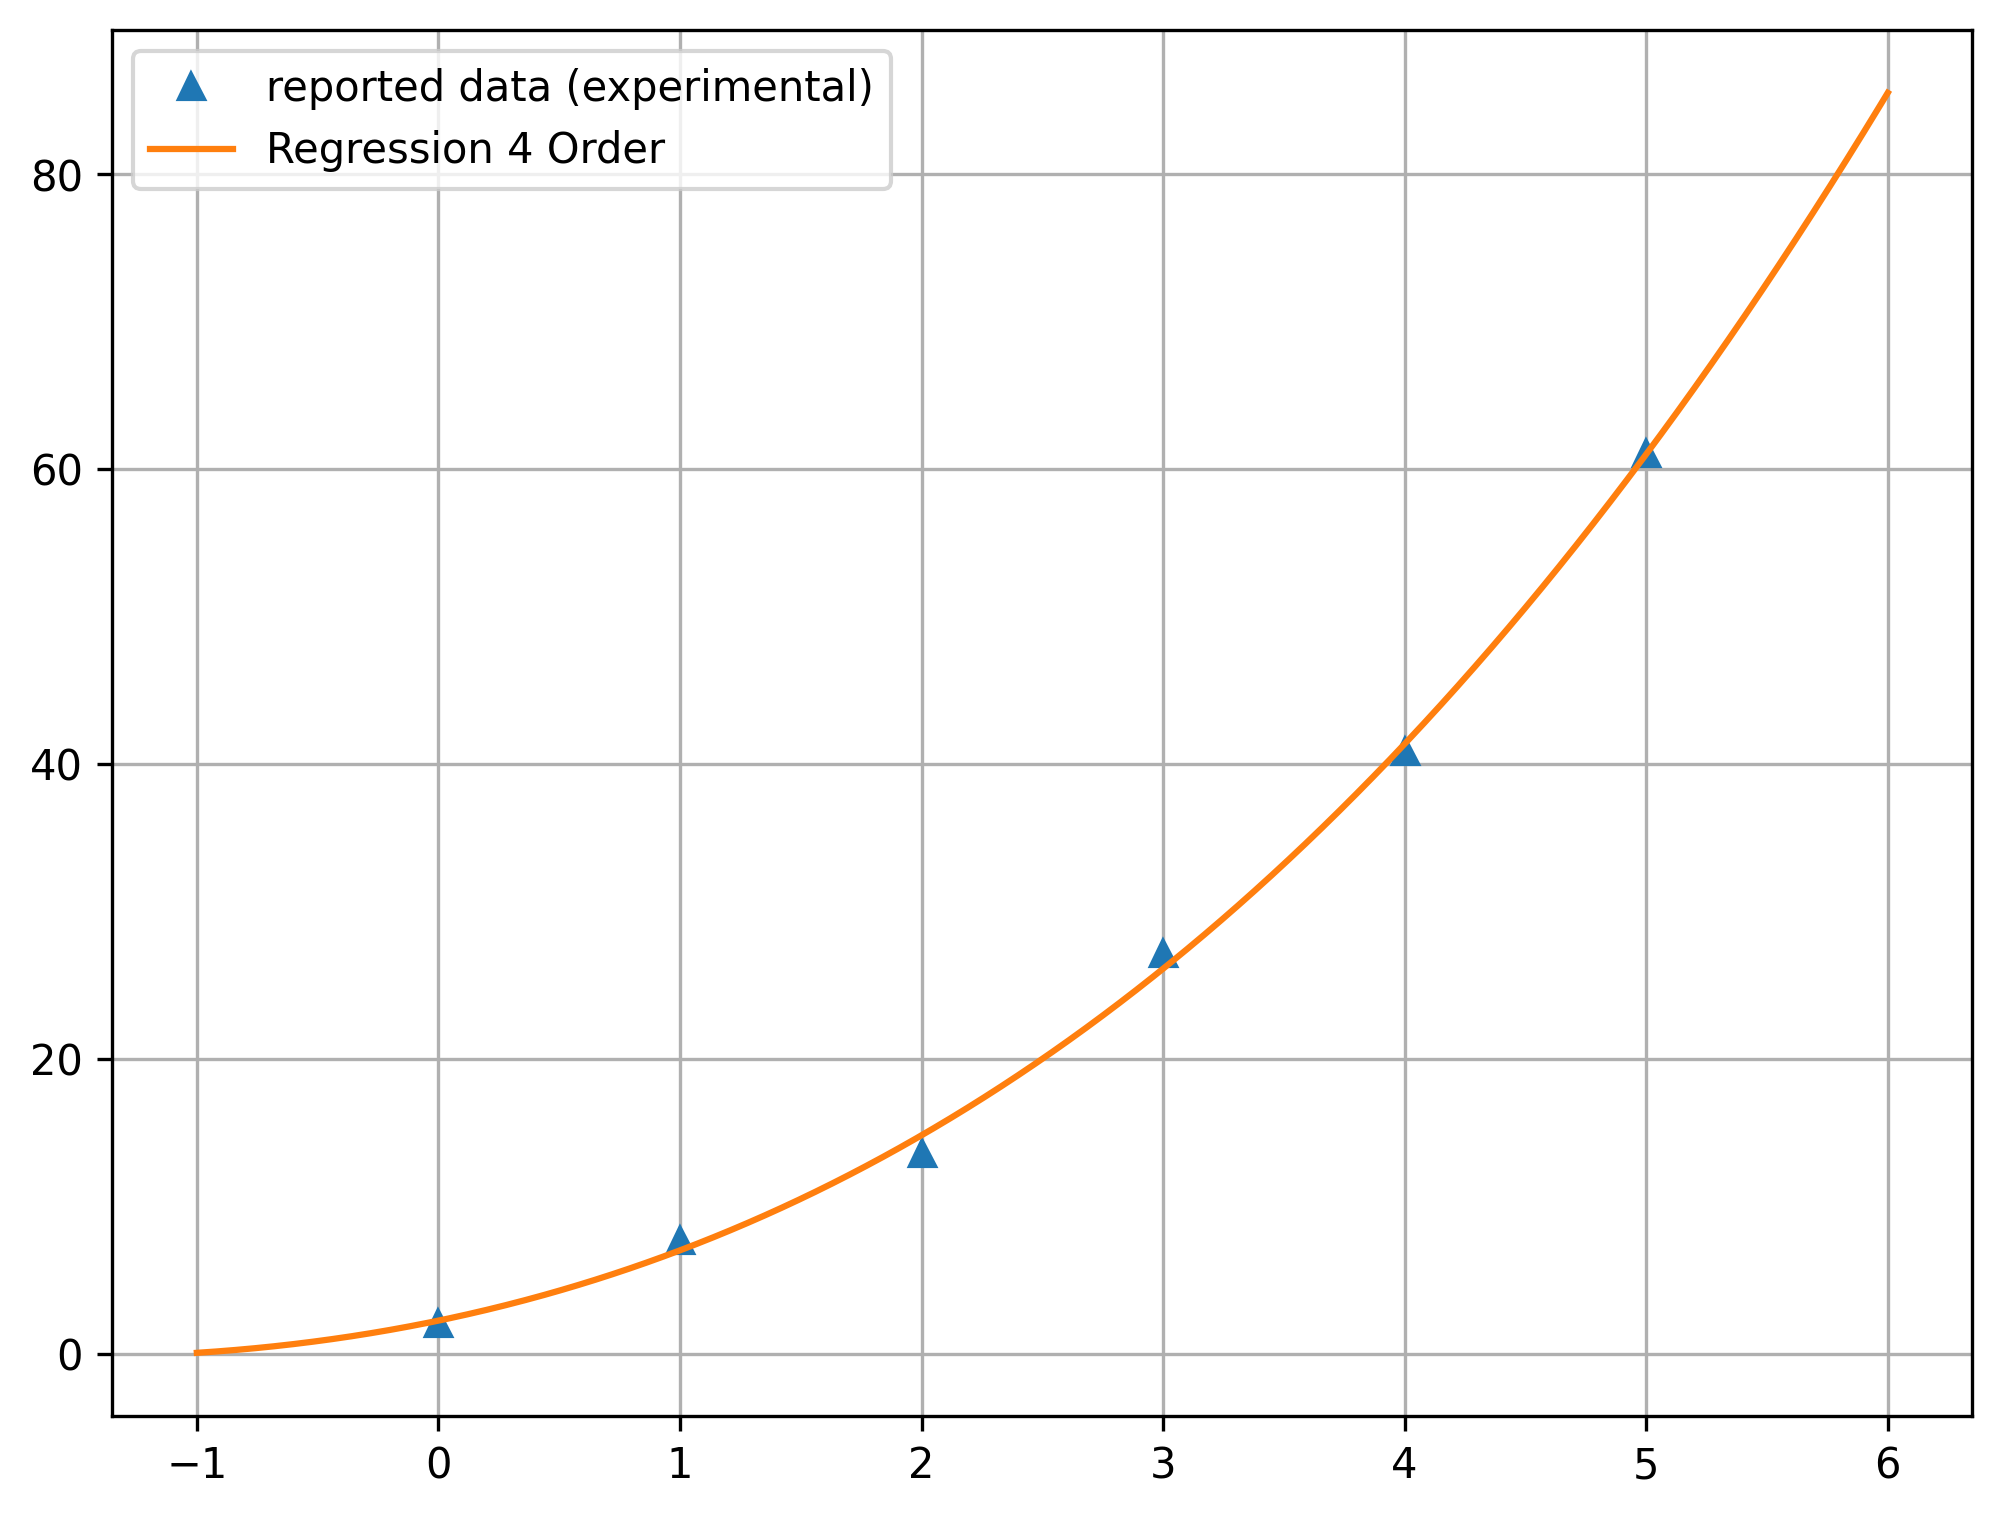

In [30]:
x = [x for x in range(6)]
y = [2.1, 7.7, 13.6, 27.2, 40.9, 61.1]
least_squares(x, y, 4)


# Integral and Derivatives


In [31]:
def trapezoidal_rule(f, a: float, b: float, n: int = 15, real_value: float = None):
    h = (b - a) / n
    x = np.arange(a, b + h, h)
    fx = f(x)
    I = 0.5 * h * (f(a) + 2 * np.sum(fx[1: -1]) + f(b))
    
    print(f"integral from a to b equals to: {I}")
    if real_value is not None:
        error = np.abs((real_value - I) / real_value) * 100
        print(f"True Absolute Error: {error}")
    return I

In [32]:
f = lambda x: 0.2 + 25 * x - 200 * x**2 + 675 * x**3 - 900 * x**4 + 400 * x**5
a = 0.0
b = 0.8
trapezoidal_rule(f, a, b, 200, 1.640533)

integral from a to b equals to: 1.6404693340159993
True Absolute Error: 0.003880810931615535


np.float64(1.6404693340159993)

In [59]:
def simpson_1_3_rule(f, a: float, b: float, n: int = 4, real_value: float = None): #n need to be even
    if n % 2 != 0:
        raise ValueError("n must be even")

    h = (b - a) / n
    x = np.arange(a, b + h, h)
    fx = f(x)
    I = h / 3 * (fx[0] + 4 * np.sum(fx[1: -1:2]) + 2 * np.sum(fx[2: -2: 2]) + fx[-1])
    #print(f"integral from a to b equals to: {I}")
    if real_value is not None:
        error = np.abs((real_value - I) / real_value) * 100
        print(f"True Absolute Error: {error}")
    return I

In [60]:
f = lambda x: 0.2 + 25 * x - 200 * x**2 + 675 * x**3 - 900 * x**4 + 400 * x**5
a = 0.0
b = 0.8
simpson_1_3_rule(f, a, b, 6, 1.640533)

True Absolute Error: 0.20547347004353134


np.float64(1.6371621399176908)

In [61]:
def simpson_3_8_rule(f, a: float, b: float, real_value: float = None):


    h = (b - a) / 3
    x = np.arange(a, b + h, h)
    I = 3 * h / 8 * (f(a) + 3 * f(a + h) + 3 * f(a + 2 * h) + f(b))
    #print(f"integral from a to b equals to: {I}")
    if real_value is not None:
        error = np.abs((real_value - I) / real_value) * 100
        print(f"True Absolute Error: {error}")
    return I

In [62]:
simpson_3_8_rule(f, a, b, 1.640533)

True Absolute Error: 7.397756072546055


1.519170370370378

In [69]:
def integration(f, a: float, b: float, n: int):

    if n < 2:
        raise ValueError("n must be >= 2")

    if n % 2 == 0:
        I = simpson_1_3_rule(f, a, b, n)
        print(f"integral from a to b equals to: {I}")
        return I

    elif n == 3:
        I = simpson_3_8_rule(f, a, b)
        print(f"integral from a to b equals to: {I}")
        return I

    else:
        # split interval
        h = (b - a)/n

        split = b - 3 * h

        I1 = simpson_1_3_rule(f, a, split, n-3)
        I2 = simpson_3_8_rule(f, split, b)
        print(f"integral from a to b equals to: {I2 + I1}")
        return I1 + I2

In [70]:
f = lambda x: 0.2 + 25 * x - 200 * x**2 + 675 * x**3 - 900 * x**4 + 400 * x**5
a = 0.0
b = 0.8
print(integration(f, a, b, 24))
print(integration(f, a, b, 27))


integral from a to b equals to: 1.6405201646090526
1.6405201646090526
integral from a to b equals to: 1.6405320900082783
1.6405320900082783


In [77]:
dx = [0.25, 0.125, 1e-3]
def backward_differences(f, x, h):
    return (f(x) - f(x - h)) / h
def forward_differences(f, x, h):
    return (f(x + h) - f(x)) / h
def center_differences(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

f = lambda x: -0.1 * x**4 - 0.15 * x**3 - 0.5 * x**2 - 0.25 * x + 12
x_est = 0.5
for h in dx:
    print(backward_differences(f, x_est, h), forward_differences(f, x_est, h), center_differences(f, x_est, h))


-0.7140625000000043 -1.1546875000000014 -0.9343750000000028
-0.8083984375000028 -1.0275390624999972 -0.91796875
-0.9116253499001914 -0.9133753501000541 -0.9125003500001228


In [80]:
def lagrande_interpolated_dev(x, y, i):
    dev1 = y[i - 1] * (x[i] - x[i + 1]) / ((x[i - 1] - x[i]) * (x[i - 1] - x[i + 1]))
    dev2 = y[i] * (2 * x[i] - x[i - 1] - x[i + 1]) / ((x[i] - x[i - 1]) * (x[i] - x[i + 1]))
    dev3 = y[i + 1] * (x[i] - x[i - 1]) / ((x[i + 1] - x[i - 1]) * (x[i + 1] - x[i]))
    return dev1 + dev2 + dev3

In [81]:
t = [4.0, 5.1, 7.0]
T = [87.2, 92.8, 104.5]
lagrande_interpolated_dev(t, T, 1)

5.48213716108453